# Getting Started with Modeling in Python

This notebook provides a practical, hands-on application of the concepts discuessed in Week 1. We will walk through the essential steps of a basic modeling workflow: loading data, performing exploratory data analysis (EDA), fitting a model, and interpreting its results.

---

## 1. Import Libraries and Load Data
First, we import the necessary libraries for data manipulation, visualization, and statistical modeling. We will use the standard "diabetes" dataset available in scikit-learn, which is pre-cleaned and scaled, making it ideal for an introductory exercise.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.datasets import load_diabetes

# Load the dataset
diabetes_dataset = load_diabetes()

# Create a Pandas dataframe for easier manipulation 
# The main data is in .data and feature names are in .feature_names
df = pd.DataFrame(data=diabetes_dataset.data, columns=diabetes_dataset.feature_names)

# The target variable (a quantitative measure of disease progression) is separate
df['progression'] = diabetes_dataset.target


---

## 2. Initial Data Exploration
Before modeling, it's crucial to understand the structure and contents of our dataset.

In [10]:
# Check the dimensions of the dataset (rows, columns)
print("Dataset shape:", df.shape)
print("="*50)

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("="*50)

# Display the first few rows to get a feel for the data
print("First 5 rows of the dataset:")
df.head()

Dataset shape: (442, 11)
Missing values per column:
age            0
sex            0
bmi            0
bp             0
s1             0
s2             0
s3             0
s4             0
s5             0
s6             0
progression    0
dtype: int64
First 5 rows of the dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


The dataset is clean and ready for analysis. Our **dependent variable** will be `progression`, and the other 10 columns will serve as potential **independent variables**.

---

## 3. Exploratory Data Analysis (EDA)
Before building a multiple regression model, it's helpful to visualize the relationships between our variables.

### Correlation Matrix
A heatmap of the correlation matrix gives us a quick overview of how all variables relate to each other. This is useful for identifying which predictors are most strongly correlated with our outcome and for spotting potential multicollinearity (strong correlations between predictors).

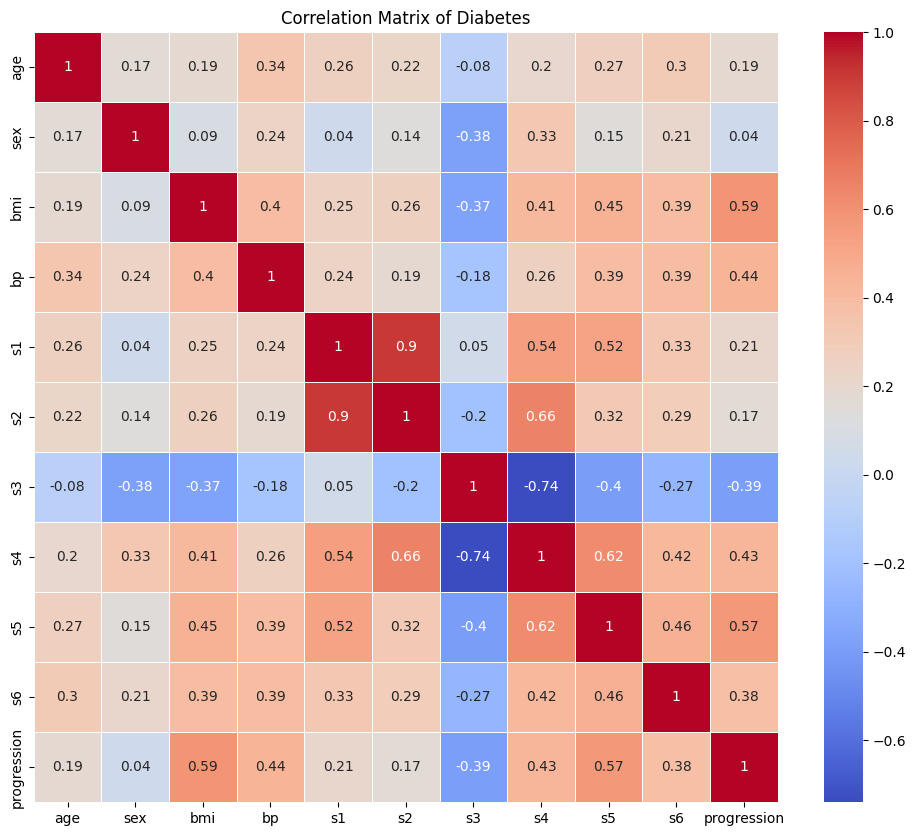

In [11]:
# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix
correlation_matrix = df.corr().round(2)

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation Matrix of Diabetes")
plt.show()

From the heatmap, we can see that `bmi`, `s5` (a measure of triglycerides), and `bp` have the strongest positive correlations with our outcome, `progression`. We also note strong correlations between some predictors, like `s1` and `s2`.

### Bivariate Scatterplots
Let's create scatterplots for a few key indicators against our outcome variable. This helps us visually assess the form, direction, and strength of each relationship. We'll add a `lowess` (locally weighted scatterplot smoothing) line to help see the pattern.

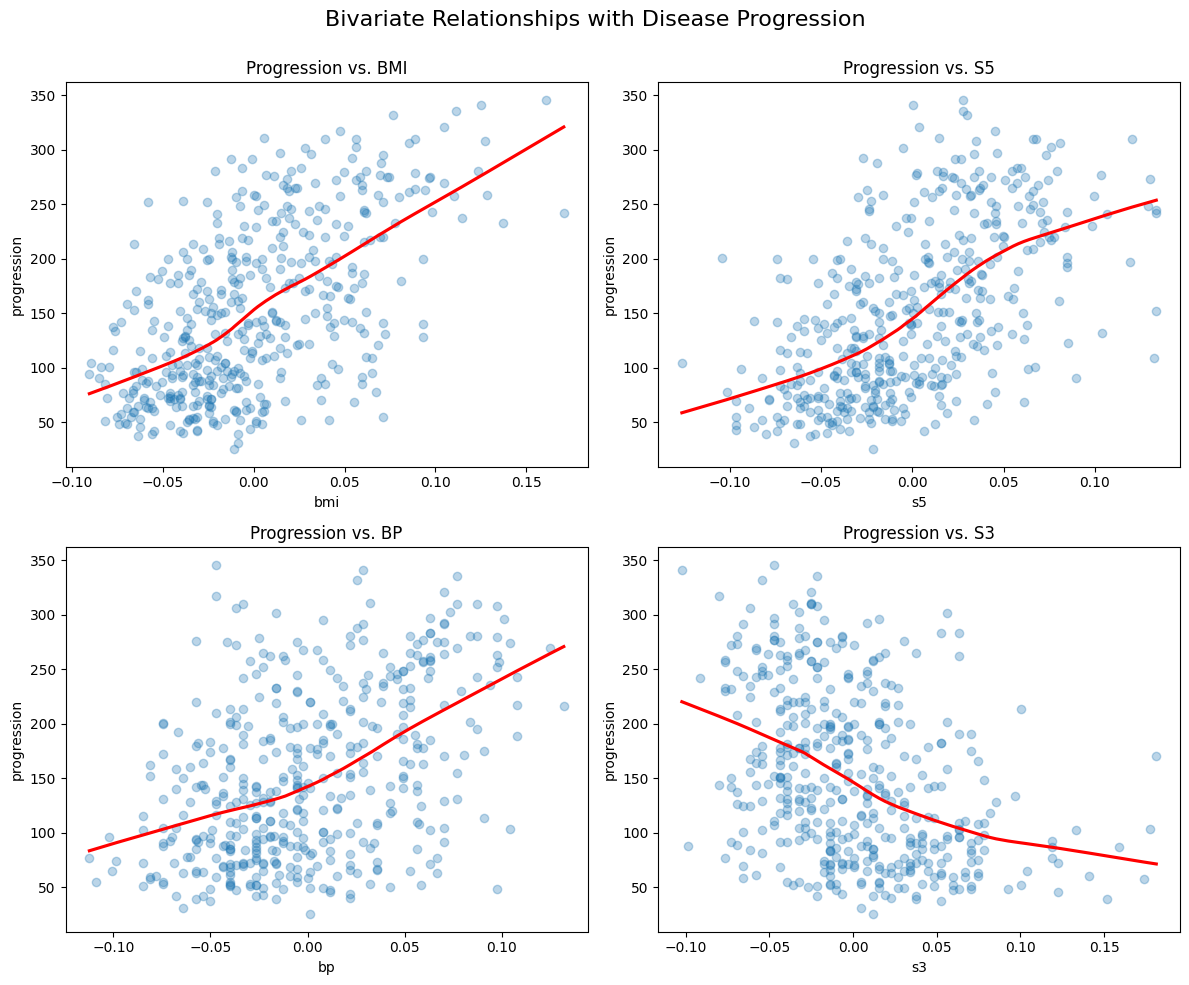

In [17]:
# Select a few key predictors based on the correlation matrix
key_predictors = ['bmi', 's5', 'bp', 's3']

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Bivariate Relationships with Disease Progression", fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, predictor in enumerate(key_predictors):
    sns.regplot(df, ax=axes[i], x=predictor, y="progression", lowess=True, scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
    axes[i].set_title(f"Progression vs. {predictor.upper()}")
    
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

The plots confirm the positive, roughly linear relationships for `bmi`, `s5`, and `bp`. The relationship with `s3` clearly negative, as expected from the correlation matrix.

### Exploring Categorical Predictors
The correlation matrix is great for continuous variables, but not as intuitive for categorical ones like `sex`. To see if `sex` has a relationship with `progression`, we can compare the distribution of the `progression` scores for each sex category.

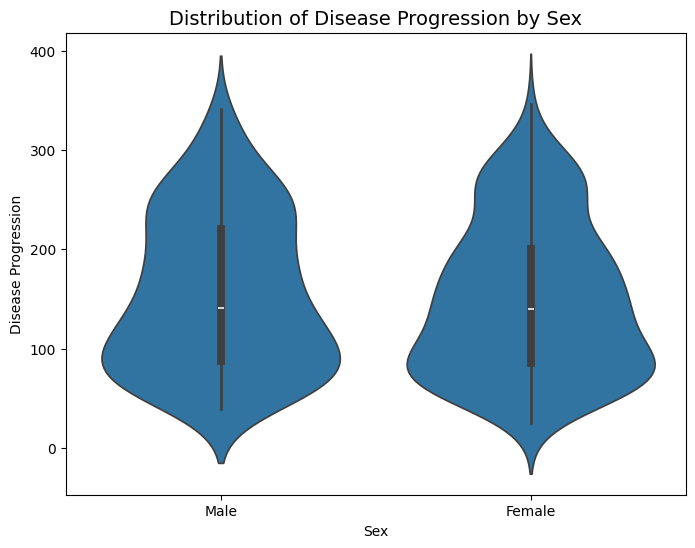

In [33]:
# The `sex` variable in this dataset is numeric. The values are approximately 0.05 for one sex 
# and -0.04 for the other. For a clearer plot, we'll create a temporary categorical label.
df['sex_label'] = df['sex'].apply(lambda x: 'Male' if x > 0 else 'Female')

# Create a box plot to compare the distributions
plt.figure(figsize=(8, 6))
sns.violinplot(df, x="sex_label", y="progression")
plt.title("Distribution of Disease Progression by Sex", fontsize=14)
plt.xlabel("Sex")
plt.ylabel("Disease Progression")
plt.show()

The violin plot shows that the distribution of `progression` scores for the "Female" group is more concentrated around its median. In contrast, the distribution of "Male" group is wider, indicating gender variability in progression scores. The median progression score also appears slightly higher for males.

This clear difference in the shape and location of the distributions provides strong visual evidence that `sex` is a relevant predictor.

---

## 4. Fitting a Linear Model
Now we will fit a multiple linear regression model using `statsmodels`, a powerful Python library for statistical modeling. We will predict `progression` using four key predictors: `bmi`, `bp`, `s5`, and `sex`. 

The formula syntax `"progression ~ bmi + bp + s5 + sex"` specifies our model, with `progression` as the dependent variable and the variables on the right as our independent variables.

In [42]:
# Using Ordinary Least Squares (OLS) from statsmodels
model = sm.OLS.from_formula("progression ~ bmi + bp + s5 + sex", data=df)
results = model.fit()

# Print the results summary
print(results.summary())
print("="*78)

                            OLS Regression Results                            
Dep. Variable:            progression   R-squared:                       0.487
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     103.6
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           5.42e-62
Time:                        15:37:19   Log-Likelihood:                -2399.8
No. Observations:                 442   AIC:                             4810.
Df Residuals:                     437   BIC:                             4830.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    152.1335      2.639     57.648      0.0


---

## 5. Interpreting the Model Results
The summary table provides a wealth of information about our model.

* **R-squared (0.487):** This tells us that our model, using these four predictors, explains about **45.7% of the variance** in the `progression` outcome. This is a reasonably a good fit. 
* **Coefficients (`coef`):** These are the estimated slopes for our predictors. 
    * The `const` (intercept) of 152.1 is the predicted disease progression for a person with all predictor values at zero (the mean, since the data is centered).
    * The coefficient for `bmi` is **598.3**. This means that, holding all other predictors constant, a one-unit increase in the scaled BMI score is associated with an estimated increase of 598.3 points in disease progression.
* **P>|t| (p-values):** This column tells us if a predictor is statistically significant. 
    * `bmi`, `bp`, and `s5` all have p-values of `0.000`, indicating they are highly significant predictors.
    * `sex` has a slightly higher p-value of `0.017`, which is still below the commonly used significance threshold of 0.05 in hypothesis testing, indicating that `sex` is also a significant predictor.

---

**Next:** [Linear Regression: Introduction](../02_fitting_models_to_independent_data/01_linear_regression--introduction.md)